In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim

### Predict apartment rent

**Import Data**

numerical features:

- **bedrooms**: The number of bedrooms in the apartment
- **bathrooms**: The number of bathrooms in the apartment
- **size_sqft**: The size of the apartment in square feet  
- **min_to_subway**: The number of minutes to the closest subway
- **floor**: The building floor of the apartment
- **building_age_yrs**: The age of the building in years
- **no_fee**: Binary indicator that specifies whether the rental has a broker's fee (1) or not (0)
- **has_roofdeck**: Binary indicator that specifies whether the rental has a roofdeck (1) or not (0)
- **has_washer_dryer**: Binary indicator that specifies whether the rental has a washer/dryer units (1) or not (0)
- **has_doorman**: Binary indicator that specifies whether the rental has a doorman (1) or not (0)
- **has_elevator**: Binary indicator that specifies whether the rental has an elevator (1) or not (0)
- **has_dishwasher**: Binary indicator that specifies whether the rental has a dishwasher (1) or not (0)
- **has_patio**: Binary indicator that specifies whether the rental has a patio (1) or not (0)
- **has_gym**: Binary indicator that specifies whether the rental has a gym (1) or not (0)
 boroughs




In [2]:
apartments_df = pd.read_csv("streeteasy.csv")

numerical_features = ['bedrooms', 'bathrooms', 'size_sqft', 'min_to_subway', 'floor', 'building_age_yrs',
                      'no_fee', 'has_roofdeck', 'has_washer_dryer', 'has_doorman', 'has_elevator', 'has_dishwasher',
                      'has_patio', 'has_gym']

# create tensor of input features
X = torch.tensor(apartments_df[numerical_features].values, dtype=torch.float)
# create tensor of targets
y = torch.tensor(apartments_df['rent'].values, dtype=torch.float).view(-1,1)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=2)

In [5]:
# set a random seed - do not modify
torch.manual_seed(42)

# Define the model using nn.Sequential
model = nn.Sequential(
    nn.Linear(14, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)

In [6]:
# MSE loss function + optimizer
loss = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 1000
for epoch in range(num_epochs):
    predictions = model(X_train) 
    MSE = loss(predictions, y_train) 
    MSE.backward()
    optimizer.step() 
    optimizer.zero_grad()
    
    # keep track of the loss during training
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], MSE Loss: {MSE.item()}')

Epoch [100/1000], MSE Loss: 3144756.75
Epoch [200/1000], MSE Loss: 3030343.5
Epoch [300/1000], MSE Loss: 2950239.0
Epoch [400/1000], MSE Loss: 2880079.25
Epoch [500/1000], MSE Loss: 2820468.25
Epoch [600/1000], MSE Loss: 2771156.5
Epoch [700/1000], MSE Loss: 2730910.0
Epoch [800/1000], MSE Loss: 2697787.75
Epoch [900/1000], MSE Loss: 2671344.25
Epoch [1000/1000], MSE Loss: 2648587.0


In [7]:
torch.save(model, 'model.pth')

In [11]:
loaded_model = torch.load('model20k.pth', weights_only=False)

In [12]:
loaded_model.eval()
with torch.no_grad():
    predictions = loaded_model(X_test)
    test_MSE = loss(predictions, y_test)
# show output
print('Test MSE is ' + str(test_MSE.item()))
print('Test Root MSE is ' + str(test_MSE.item()**(1/2)))

Test MSE is 1997976.625
Test Root MSE is 1413.4980102568238


**Visualization**

plot our model's predictions against the actual targets, for the test dataset. If our model was perfect, all the dots would be on the dashed line. 

Text(0.5, 1.0, 'StreetEasy Dataset - Predictions vs Actual Values')

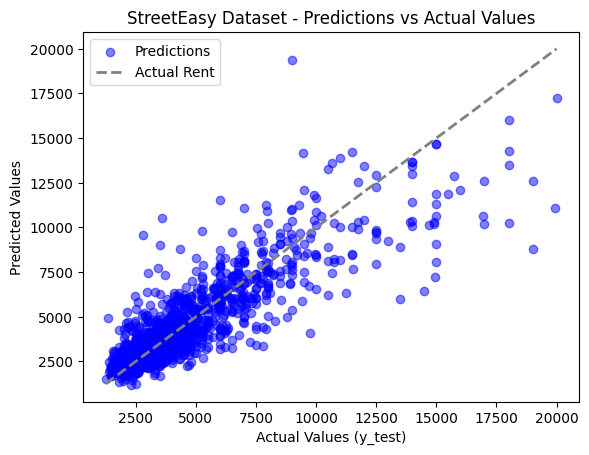

In [14]:
plt.scatter(y_test, predictions, label='Predictions', alpha=0.5, color='blue')

plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values')

plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='gray', linewidth=2,
         label="Actual Rent")
plt.legend()
plt.title('StreetEasy Dataset - Predictions vs Actual Values')